In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
# read the preprepared dataset
df = pd.read_csv('PreProcesseddataset_ifn580_262_v1.csv')

# Preprocess The Data

In [2]:
# goal is to predict the is_accepted bool

# Obtain a list of labels (targets) for each of the samples. We refer to this as 'y'.
y = df["is_accepted"].values

# Remove the label (target) from the samples, as this is not a feature that we want to use to predict against.
# axis=1 is used to drop the column, instead of the row.
X = df.drop(['is_accepted'], axis=1)

# Pull out the column names before grabbing the feature array, we will need it later
feature_names = X.columns

# We use X.values to get arrays for the features, instead of a DataFrame with column names etc.
X = X.values

### split data into traing and test set

In [3]:
from sklearn.model_selection import train_test_split
# Create a 30% train/test split from our samples.
# We set the random_state to the constant 10 to ensure it is the same from run-to-run.
# We set the stratisfy parameter to the labels, that way we get an even selection of 0 and 1 values in our testing set.
# Otherwise, we may end up with unbalanced 0/1 labels across the two splits.
random_state = 10
test_set_size = 0.3 # 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_set_size,
stratify=y, random_state=random_state)
print("Size of training set:", len(X_train))
print("Size of testing set:", len(X_test))

Size of training set: 8878
Size of testing set: 3806


### Standardise values

In [4]:
from sklearn.preprocessing import StandardScaler

# initialise a standard scaler object
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train, y_train)
X_test = scaler.transform(X_test)

print(X_train[0:5])

[[ 0.30197984 -0.71283471 -0.48142291  0.85826695  0.77373499 -0.48943486
  -1.12540238 -0.97816136 -1.05045602 -1.58797979 -0.8283899  -0.90518567
  -0.26713202 -0.68792514 -0.94022351 -0.4543266  -1.52210467 -1.39313343
  -1.44604428  0.88694836  2.70997878 -0.52303145]
 [-0.91278093  0.34598184 -0.48142291  0.85826695 -0.71339065 -0.48943486
  -1.12540238 -0.97816136 -1.05045602  0.78523536  1.20716103 -0.90518567
  -0.89947388 -0.68792514 -0.94022351  1.98529733 -0.44826128  1.86968013
   0.83443909 -1.12746135 -0.36900658 -0.52303145]
 [-0.91278093  0.34598184 -0.48142291 -0.45298653  0.03017217 -0.48943486
  -1.12540238 -0.97816136 -0.58273204 -0.40137222 -0.8283899   0.6848892
   1.31372261  1.26807005 -0.94022351 -0.4543266  -1.52210467 -0.30552891
  -0.3058026  -1.12746135 -0.36900658 -0.52303145]
 [ 1.5167406  -0.71283471  1.02938395 -0.45298653 -1.27106277  0.27759121
  -1.12540238 -0.97816136 -1.51818001 -1.58797979 -0.8283899  -0.90518567
  -0.89947388  1.65926909 -0.03566

# Train The Model

In [5]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=random_state)

# fit it to training data
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,10
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Test Model Accuracy

In [6]:
from sklearn.metrics import classification_report
# training and test accuracy
print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

# classification report on test data
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Train accuracy: 0.638432079297139
Test accuracy: 0.651077246452969
              precision    recall  f1-score   support

           0       0.63      0.47      0.54      1643
           1       0.66      0.79      0.72      2163

    accuracy                           0.65      3806
   macro avg       0.64      0.63      0.63      3806
weighted avg       0.65      0.65      0.64      3806



# Fine Tuning The Model

In [7]:
# grab feature importances from the model and feature name from the original X
coef = model.coef_[0]

# sort them out in descending order
indices = np.argsort(np.absolute(coef))
indices = np.flip(indices, axis=0)

In [8]:
from sklearn.model_selection import GridSearchCV

# grid search CV
params = {'C': [pow(10, x) for x in range(-6, 4)]}

# use all cores to tune logistic regression with C parameter
cv = GridSearchCV(param_grid=params,
estimator=LogisticRegression(random_state=random_state), cv=10, n_jobs=-1)
cv.fit(X_train, y_train)

# test the best model
print("Train accuracy:", cv.score(X_train, y_train))
print("Test accuracy:", cv.score(X_test, y_test))
y_pred = cv.predict(X_test)
print(classification_report(y_test, y_pred))

Train accuracy: 0.6388826312232485
Test accuracy: 0.651602732527588
              precision    recall  f1-score   support

           0       0.63      0.47      0.54      1643
           1       0.66      0.79      0.72      2163

    accuracy                           0.65      3806
   macro avg       0.65      0.63      0.63      3806
weighted avg       0.65      0.65      0.64      3806



# Recursive Feature Elimination

In [9]:
from sklearn.feature_selection import RFECV

rfe = RFECV(estimator = LogisticRegression(random_state=random_state), cv=10)

# run the RFECV
rfe.fit(X_train, y_train)

# comparing how many variables before and after
print("Original feature set", X_train.shape[1])
print("Number of features after elimination", rfe.n_features_)

Original feature set 22
Number of features after elimination 11


In [10]:
X_train_sel = rfe.transform(X_train)
X_test_sel = rfe.transform(X_test)

In [11]:
# grid search CV
params = {'C': [pow(10, x) for x in range(-6, 4)]}
rfe_cv = GridSearchCV(param_grid=params,
estimator=LogisticRegression(random_state=random_state), cv=10, n_jobs=-1)
rfe_cv.fit(X_train_sel, y_train)

# test the best model
print("Train accuracy:", rfe_cv.score(X_train_sel, y_train))
print("Test accuracy:", rfe_cv.score(X_test_sel, y_test))

y_pred = rfe_cv.predict(X_test_sel)
print(classification_report(y_test, y_pred))

# print parameters of the best model
print(cv.best_params_)

Train accuracy: 0.6387699932417211
Test accuracy: 0.6523909616395166
              precision    recall  f1-score   support

           0       0.63      0.46      0.53      1643
           1       0.66      0.80      0.72      2163

    accuracy                           0.65      3806
   macro avg       0.65      0.63      0.63      3806
weighted avg       0.65      0.65      0.64      3806

{'C': 0.1}


# Selecting the Best Model

In [12]:
from sklearn.metrics import roc_auc_score

y_pred_proba_lr = model.predict_proba(X_test)
y_pred_proba_lr_cv = cv.predict_proba(X_test)
y_pred_proba_rfe_cv = rfe_cv.predict_proba(X_test_sel)

roc_index_lr = roc_auc_score(y_test, y_pred_proba_lr[:, 1])
roc_index_lr_cv = roc_auc_score(y_test, y_pred_proba_lr_cv[:, 1])
roc_index_rfe_cv = roc_auc_score(y_test, y_pred_proba_rfe_cv[:, 1])

print("ROC index on test for `model`:", roc_index_lr)
print("ROC index on test for `cv`:", roc_index_lr_cv)
print("ROC index on test for `rfe_cv`:", roc_index_rfe_cv)

ROC index on test for `model`: 0.6971501563533663
ROC index on test for `cv`: 0.6971898320928334
ROC index on test for `rfe_cv`: 0.6963355374472855


In [13]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_proba_lr[:,1])
fpr_lr_cv, tpr_lr_cv, thresholds_lr_cv = roc_curve(y_test, y_pred_proba_lr_cv[:,1])
fpr_rfe_cv, tpr_rfe_cv, thresholds_rfe_cv = roc_curve(y_test, y_pred_proba_rfe_cv[:,1])

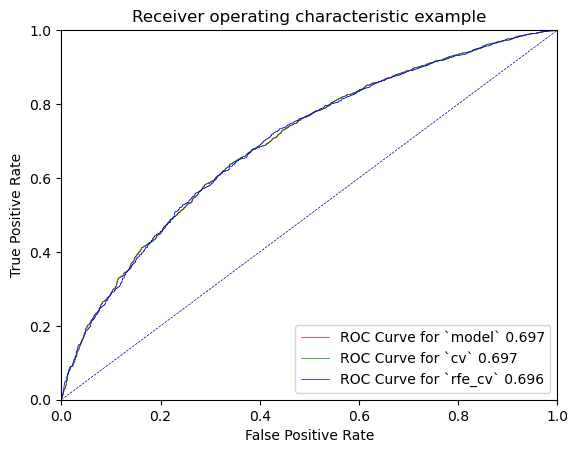

In [14]:
import matplotlib.pyplot as plt
plt.plot(fpr_lr, tpr_lr, label=f'ROC Curve for `model` {roc_index_lr:.3f}', color='red',
lw=0.5)
plt.plot(fpr_lr_cv, tpr_lr_cv, label=f'ROC Curve for `cv` {roc_index_lr_cv:.3f}',
color='green', lw=0.5)
plt.plot(fpr_rfe_cv, tpr_rfe_cv, label=f'ROC Curve for `rfe_cv` {roc_index_rfe_cv:.3f}',
color='blue', lw=0.5)

plt.plot([0, 1], [0, 1], color='navy', lw=0.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [15]:
import pickle

lr_best = cv
roc_index_lr_best = roc_index_lr_cv
tpr_lr_best = tpr_lr_cv
fpr_lr_best = fpr_lr_cv

with open('LR.pickle', 'wb') as f:
    pickle.dump([lr_best,roc_index_lr_best, fpr_lr_best, tpr_lr_best,scaler], f)